In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


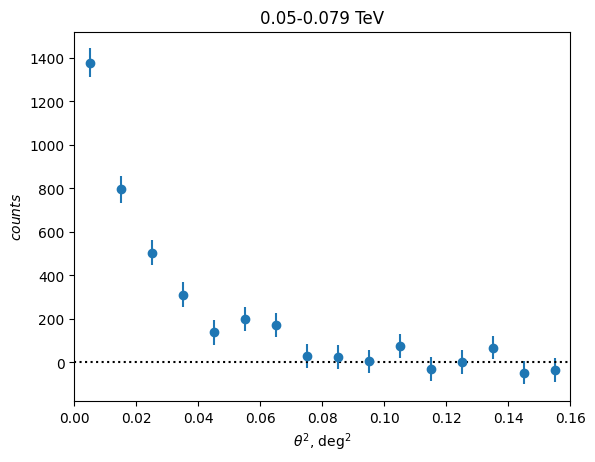

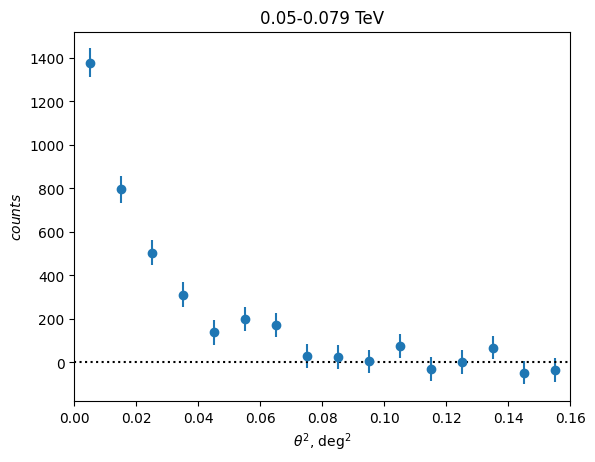

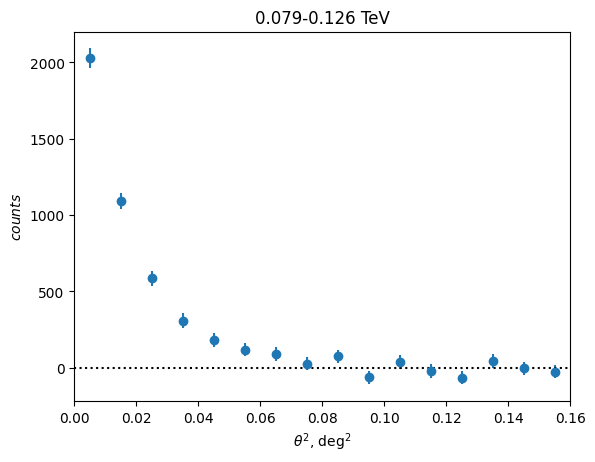

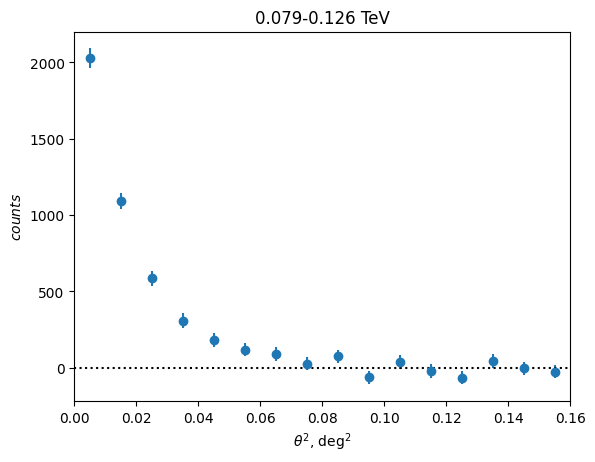

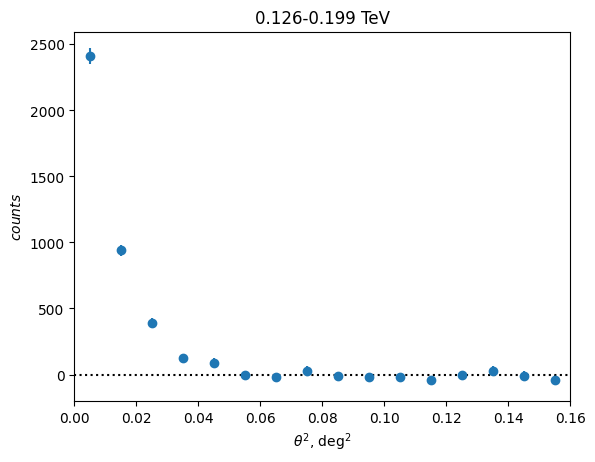

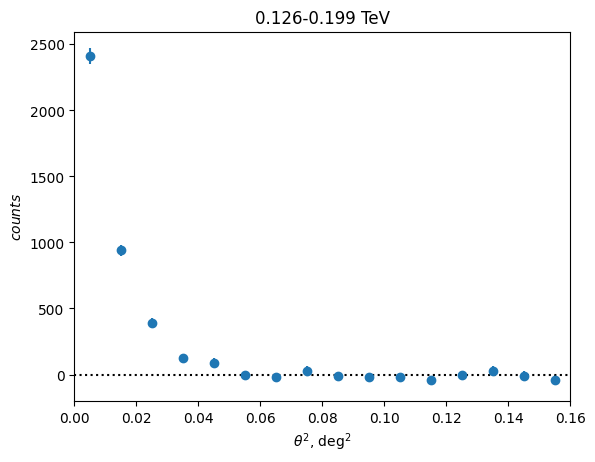

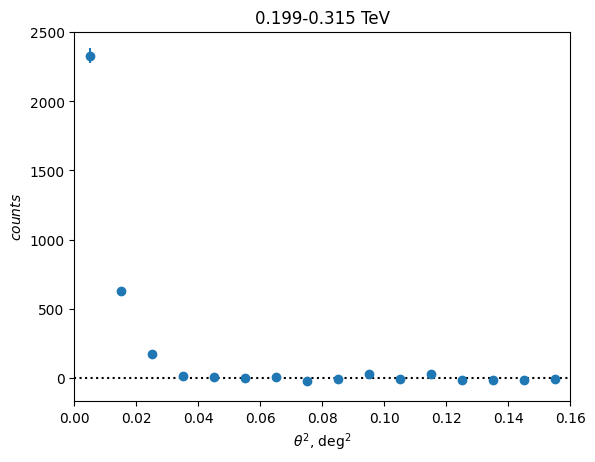

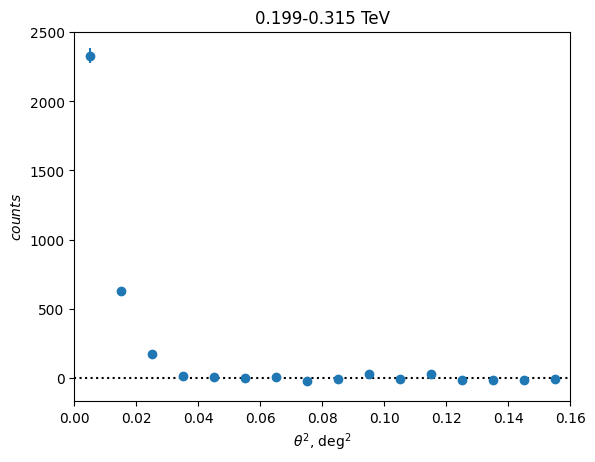

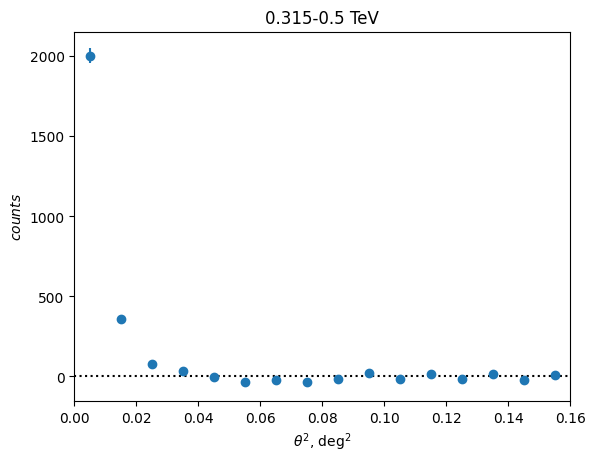

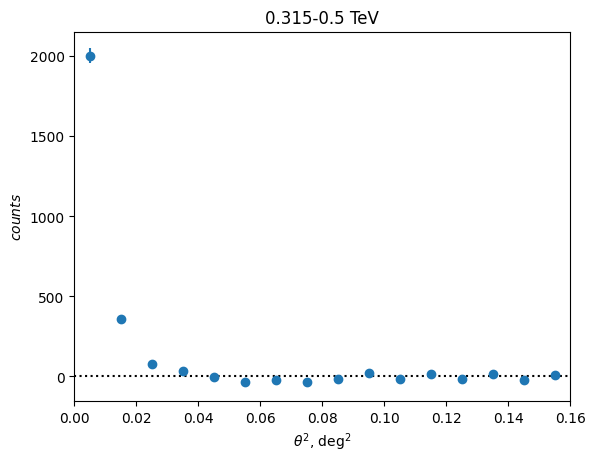

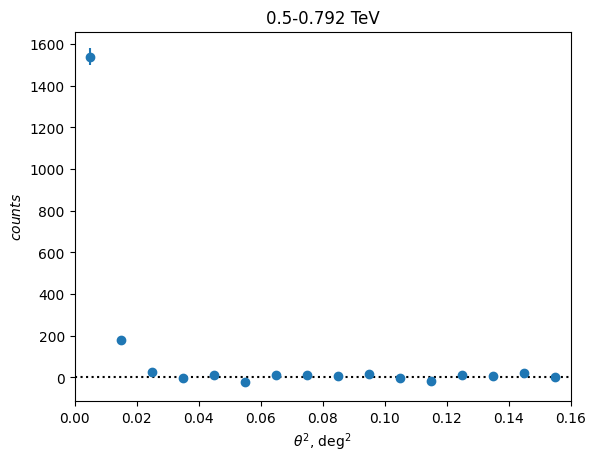

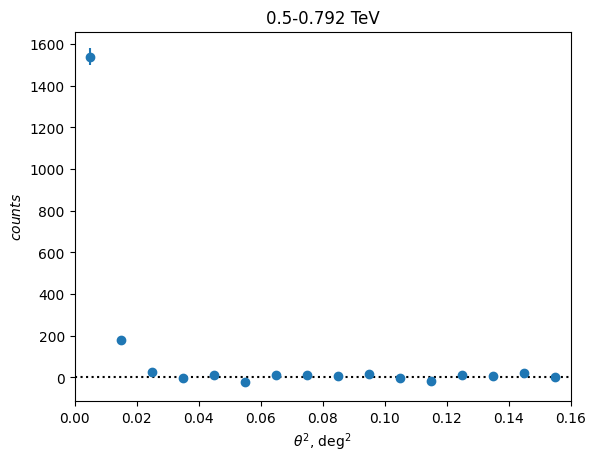

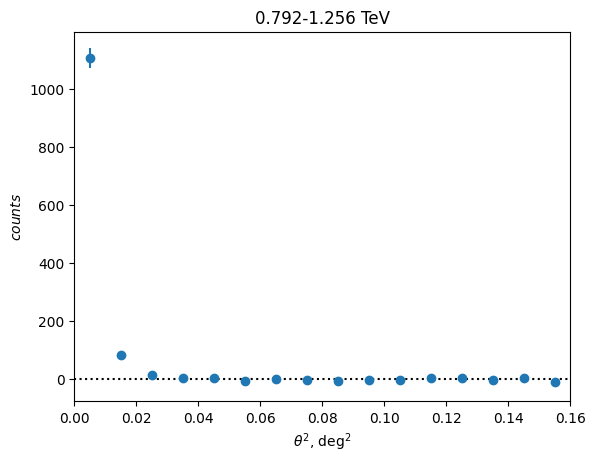

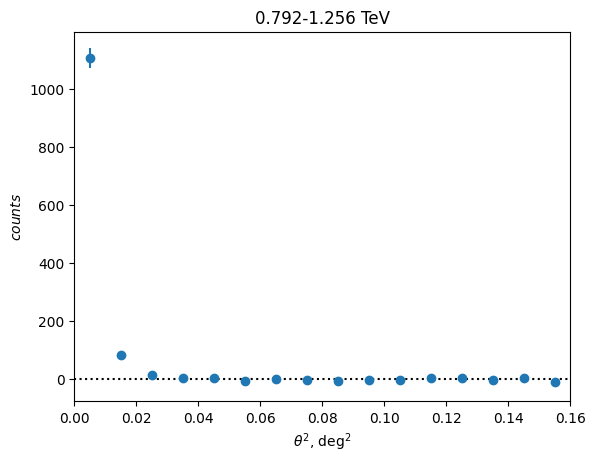

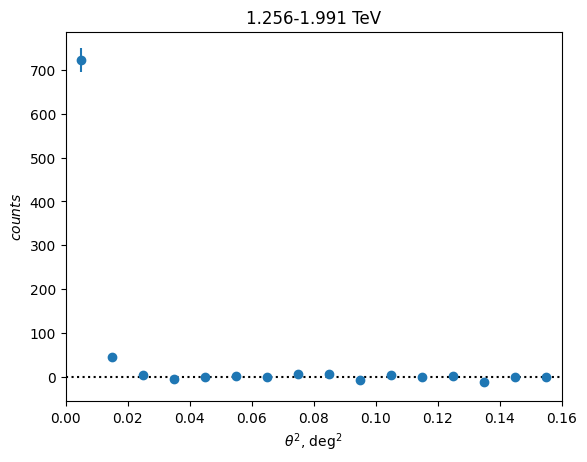

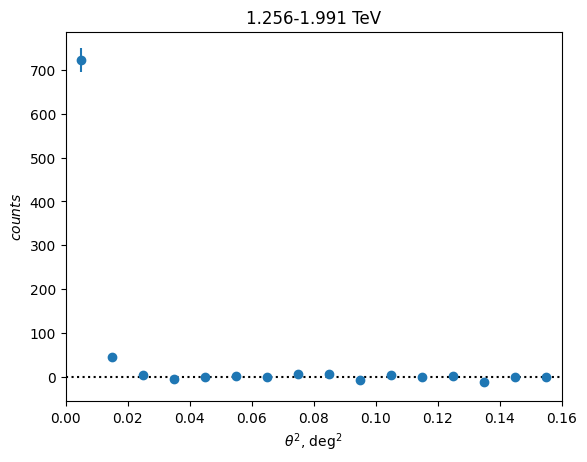

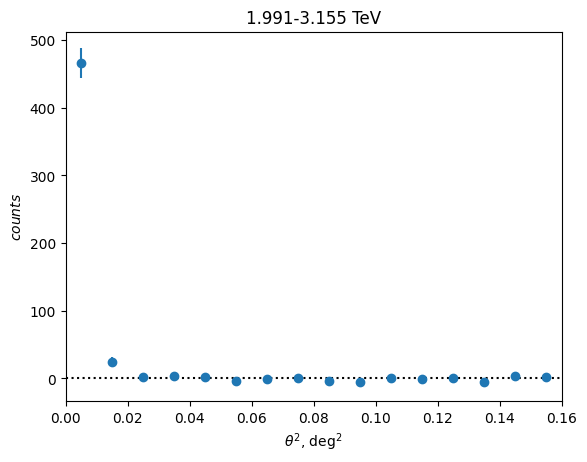

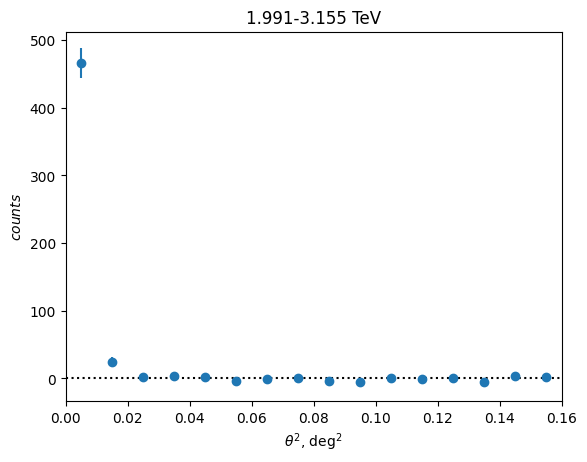

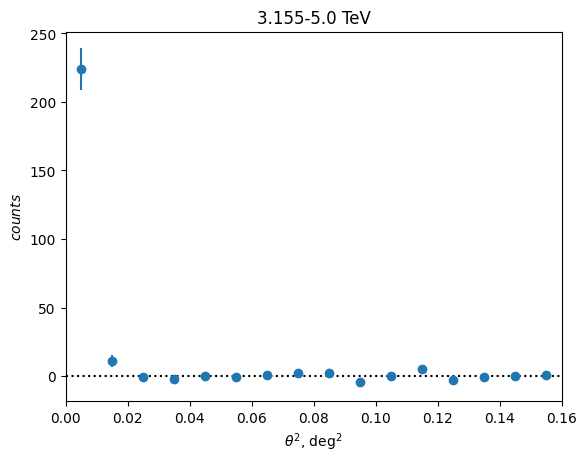

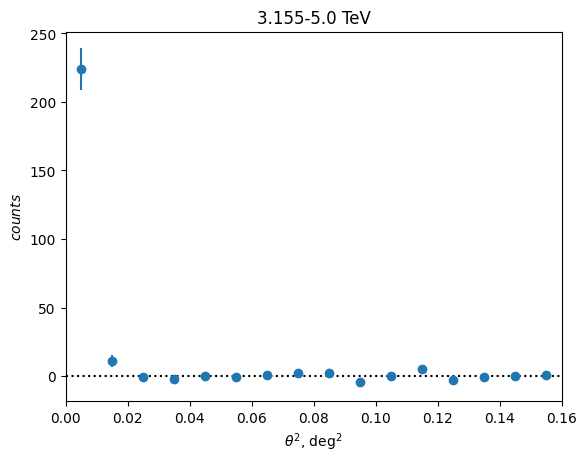

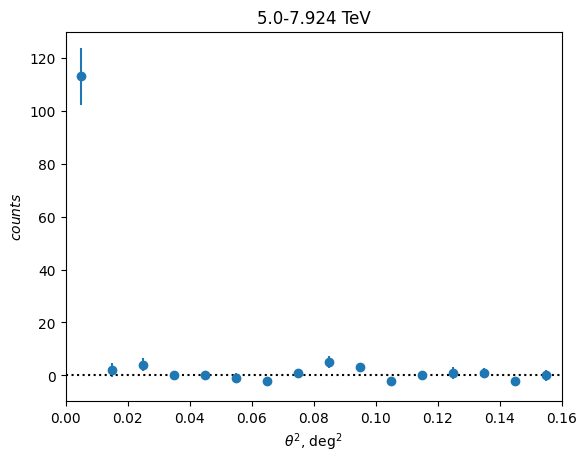

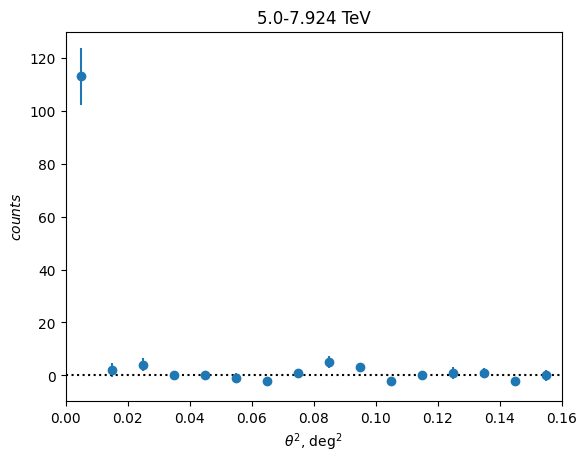

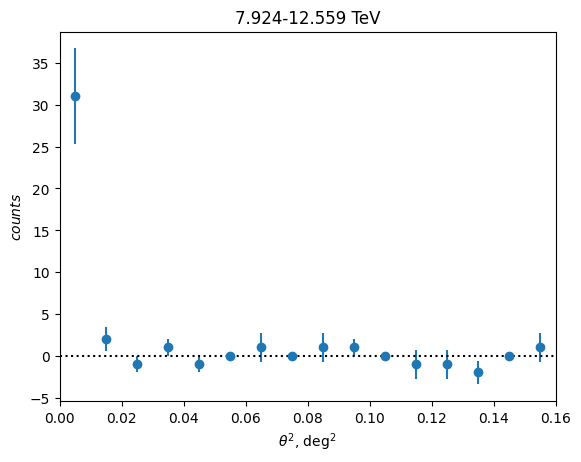

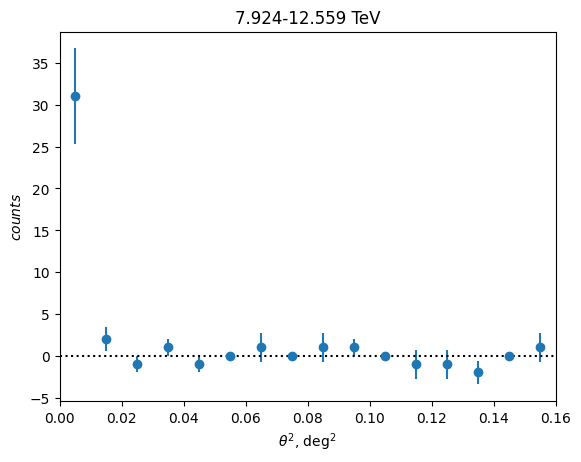

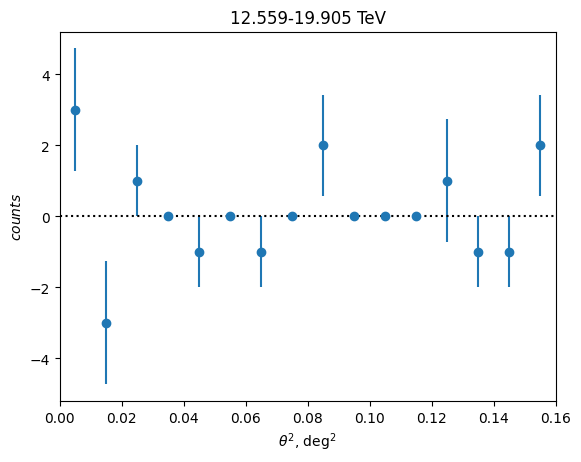

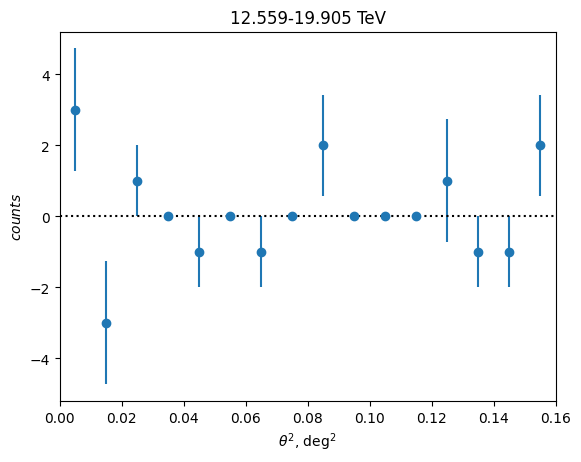

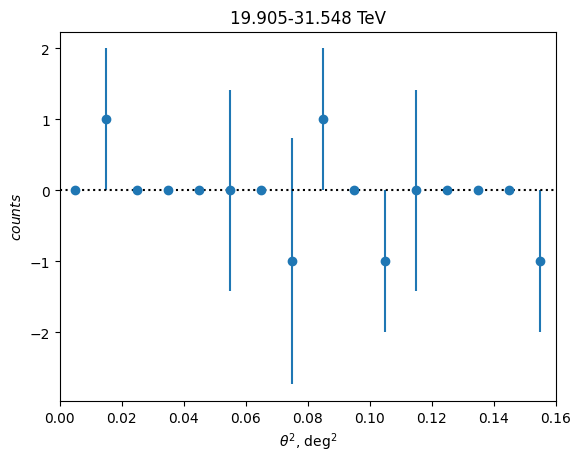

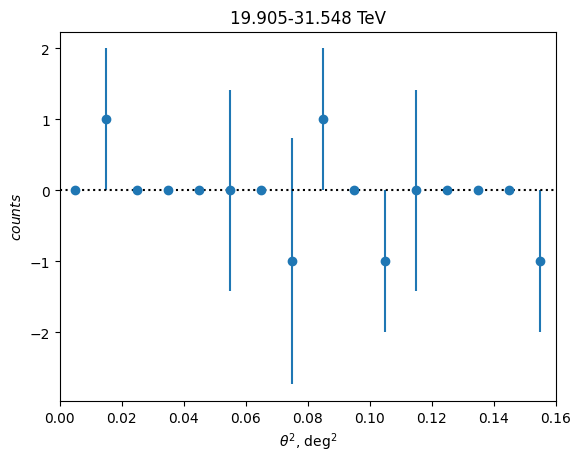

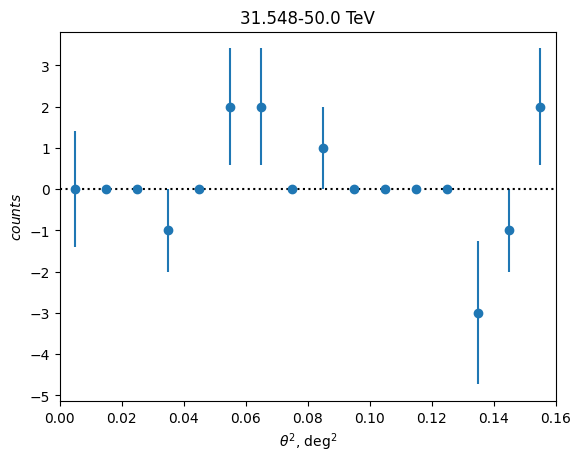

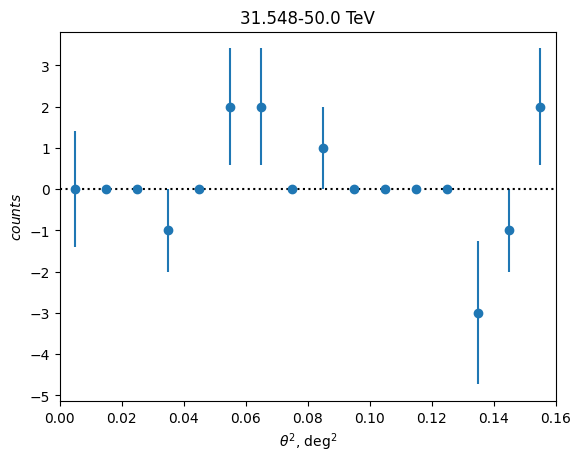

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)


for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

converged at 
719
2.7227219508541403
converged at 
667
2.7573219105122106
converged at 
635
2.7199308138327343
converged at 
619
2.7314821092331236


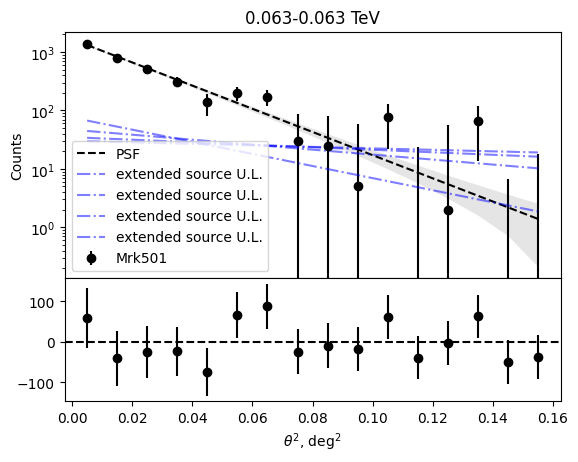

converged at 
753
2.7367486252098043
converged at 
690
2.7547616045578724
converged at 
647
2.7392225772029555
converged at 
626
2.7698651506160434


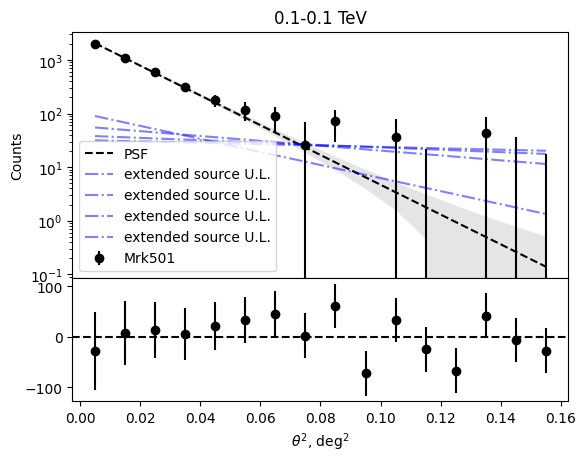

converged at 
645
2.7187000186433377
converged at 
529
2.7190348691398025
converged at 
486
2.7365819716596
converged at 
467
2.7284344923611563


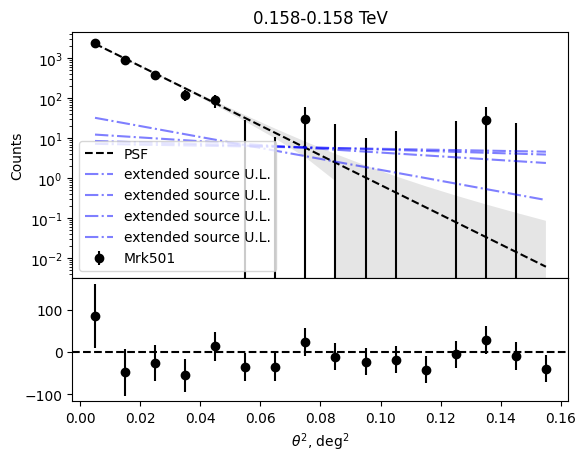

converged at 
584
2.7182701270639065
converged at 
492
2.7322493769470526
converged at 
461
2.734222693447009
converged at 
447
2.725582232273055


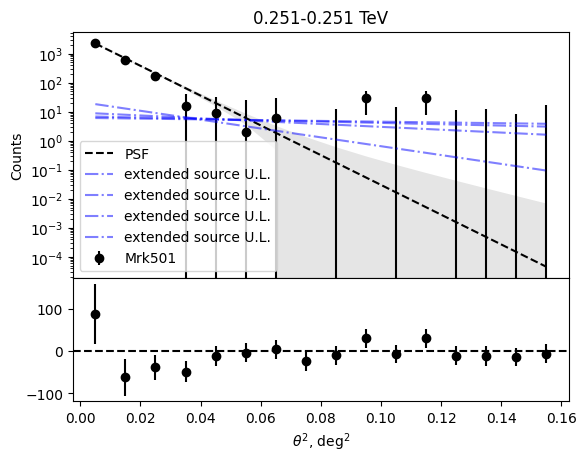

converged at 
552
2.710470073942872
converged at 
425
2.726759862699737
converged at 
387
2.730621867371429
converged at 
372
2.736293608067072


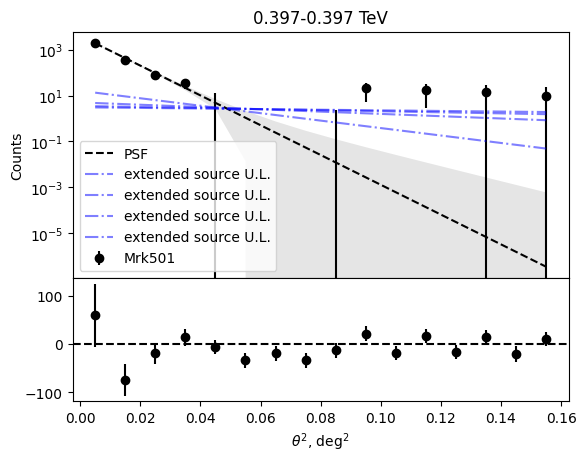

converged at 
504
2.718435706489771
converged at 
463
2.7145166656651583
converged at 
460
2.758870956214267
converged at 
456
2.7628909821183356


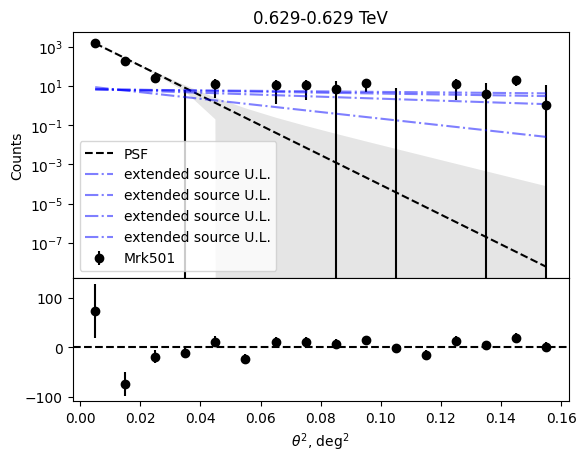

converged at 
493
2.7141679064643505
converged at 
382
2.736039692758112
converged at 
339
2.7186333657422956
converged at 
321
2.731707229540028


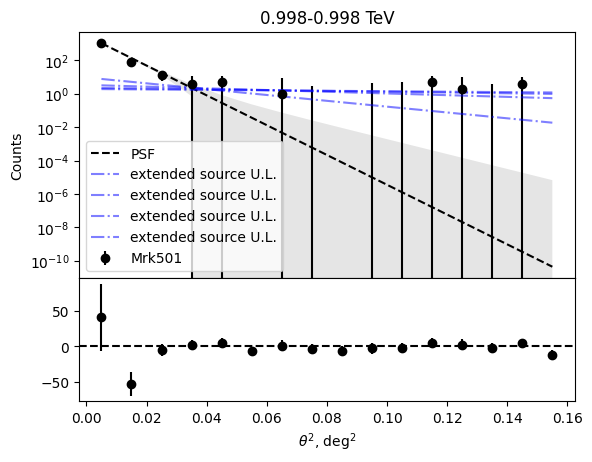

converged at 
445
2.719092033901358
converged at 
347
2.7242077391003825
converged at 
305
2.7338344962303864
converged at 
285
2.712759569061191


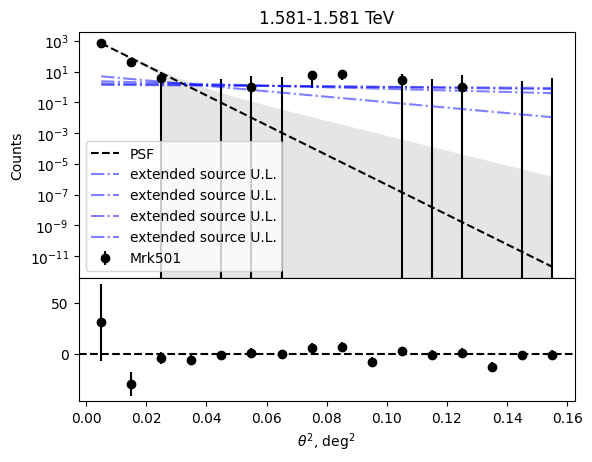

converged at 
462
2.7242992101642827
converged at 
333
2.7376452693620656
converged at 
291
2.7370904107298095
converged at 
274
2.732146311084513


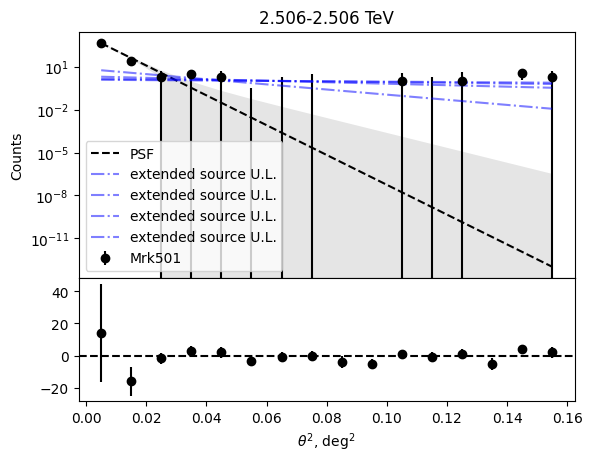

converged at 
377
2.714192437709599
converged at 
257
2.742682205495015
converged at 
218
2.733754440830964
converged at 
202
2.7437615533649335


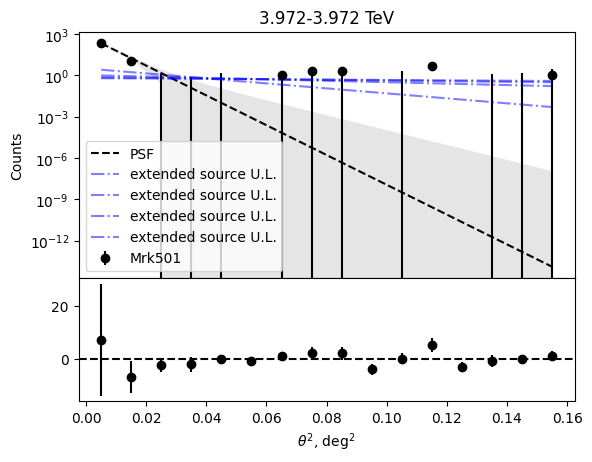

converged at 
434
2.7249997155899734
converged at 
315
2.767473553621322
converged at 
269
2.7541226711409514
converged at 
249
2.766796259764611


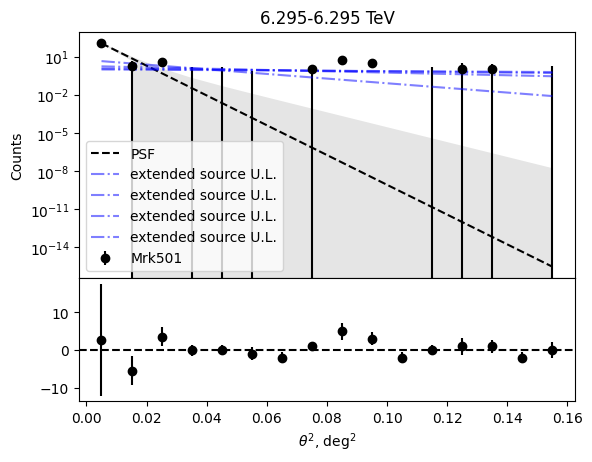

converged at 
0
28484394249.47579
converged at 
0
242200534128024.8
converged at 
0
1627221399268158.0
converged at 
0
3231555126279494.0


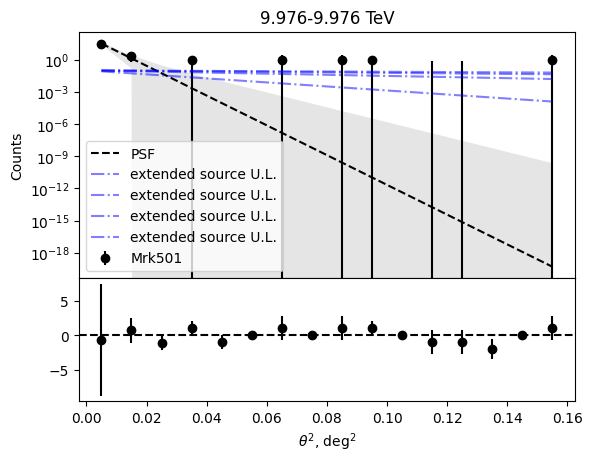

converged at 
0
946082854514.508
converged at 
0
1564987203554879.2
converged at 
0
7188055776250961.0
converged at 
0
1.2410332511519868e+16


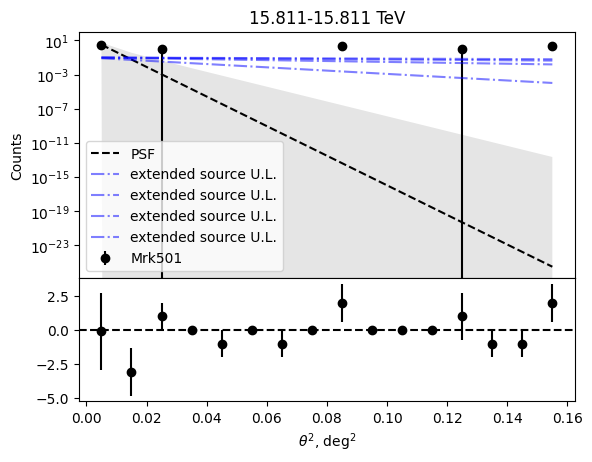

/tmp/ipykernel_4078/2422177958.py:26: RuntimeWarning: invalid value encountered in sqrt
  psf_component_err = np.sqrt(psf_component)


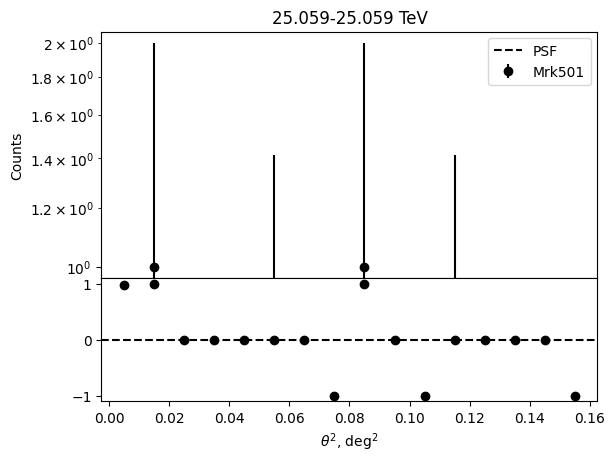

converged at 
0
2.847709263509779e+37
converged at 
0
1.3658835996584629e+41
converged at 
0
7.363756486071381e+41
converged at 
0
1.3401967329596348e+42


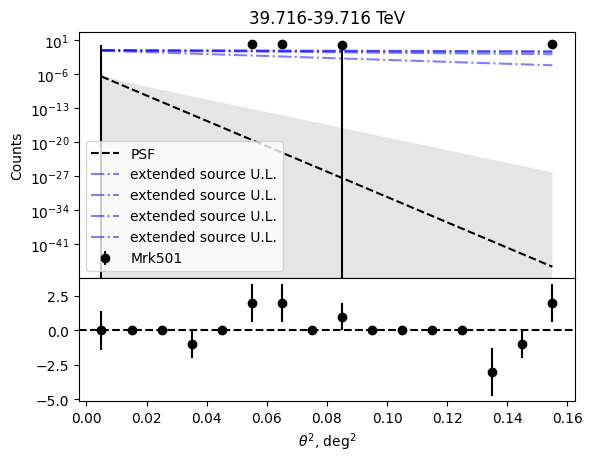

In [8]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.logspace(np.log10(0.1), np.log10(1000), 1000)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the psf component to match total counts of the data
    psf_component *= sum(ct)/sum(psf_component)
    #psf_component_err = ct_err*sum(psf_component)/sum(ct)
    psf_component_err = np.sqrt(psf_component)
    
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
    # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
    # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            # here i renormalize the point source taking away te extended emission counts. (...NOT)
            #no_ext_renormaliz = 1 - np.sum(ct_ext)/np.sum(psf_component)
            #ct_ext_plus_src = ct_ext+psf_component*no_ext_renormaliz
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
                              
            delta_chi2 = chi2_ext - chi2_noext
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(psf_component) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    axs[0].legend()
    axs[0].set_yscale('log')
    plt.show()

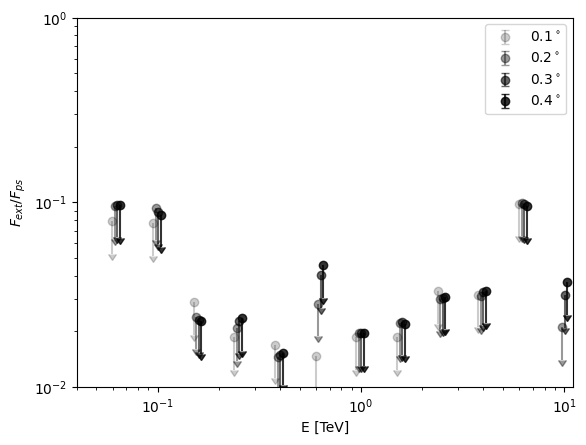

In [9]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()

Here i do the same algorithm as andrii to se if its any different

fraction U.L. 0.30215686742536674
fraction U.L. 0.2052510617092434
fraction U.L. 0.1822222056298677
fraction U.L. 0.1734815440010779
fraction U.L. 0.24542327969109343
fraction U.L. 0.16617672730985783
fraction U.L. 0.14528639826502374
fraction U.L. 0.13597539135018427
fraction U.L. 0.05311225418830354
fraction U.L. 0.04224770647332472
fraction U.L. 0.04100520767554791
fraction U.L. 0.04059921552034449
fraction U.L. 0.03103419965990406
fraction U.L. 0.03394164711758302
fraction U.L. 0.037121479583150124
fraction U.L. 0.038246297535999084
fraction U.L. 0.028375804662462954
fraction U.L. 0.025688245789844057
fraction U.L. 0.02699860449456509
fraction U.L. 0.027541276444905807
fraction U.L. 0.02023119225701618
fraction U.L. 0.03497011296689252
fraction U.L. 0.04713442883149269
fraction U.L. 0.05258639028544145
fraction U.L. 0.023959890641942157
fraction U.L. 0.028094856101448445
fraction U.L. 0.029823255879922857
fraction U.L. 0.03012148843872214
fraction U.L. 0.023959890641942146
fraction

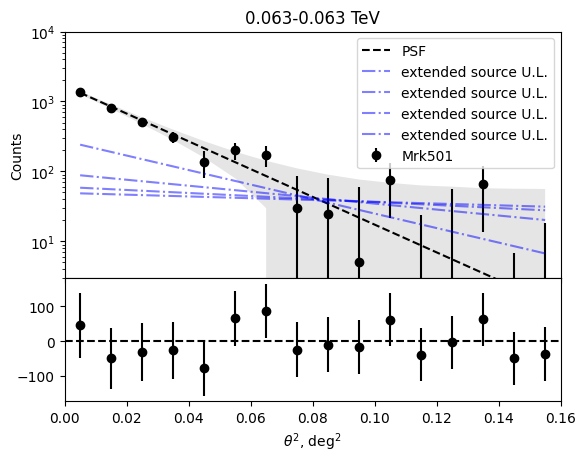

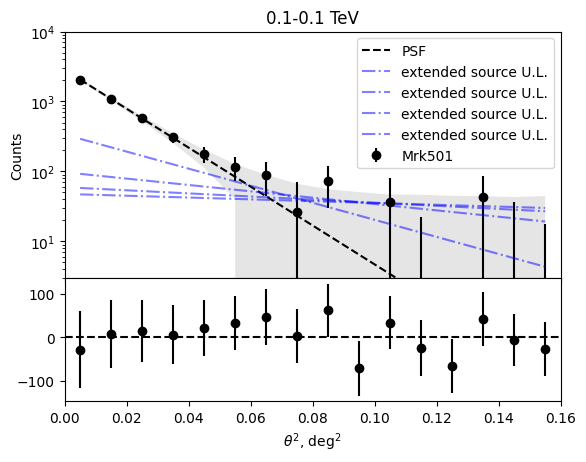

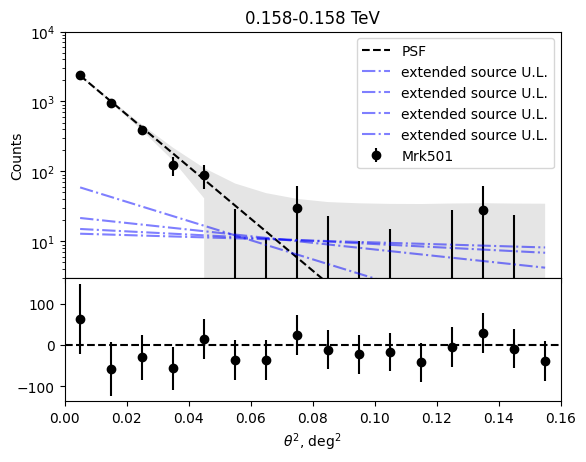

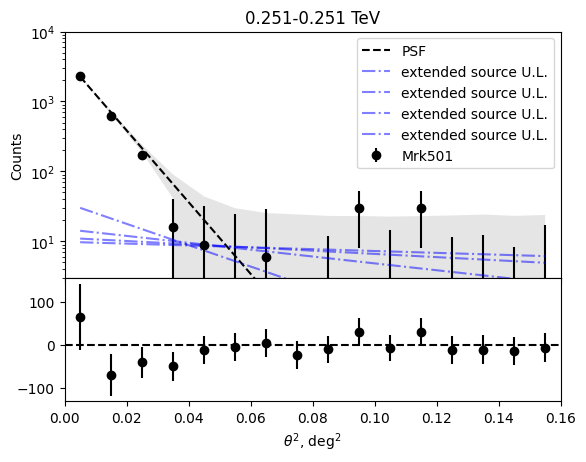

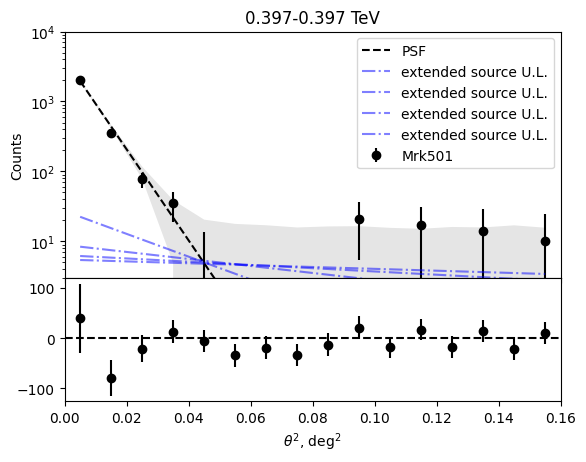

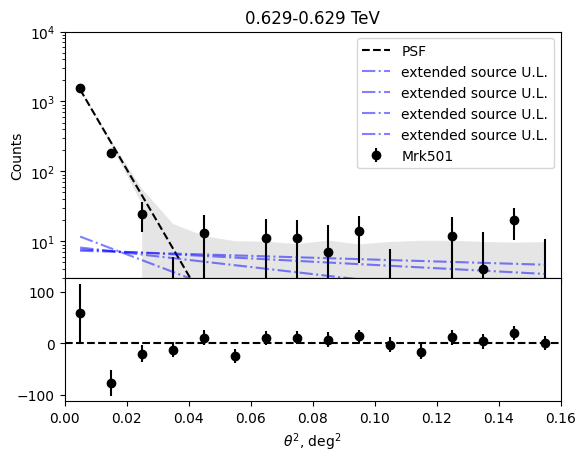

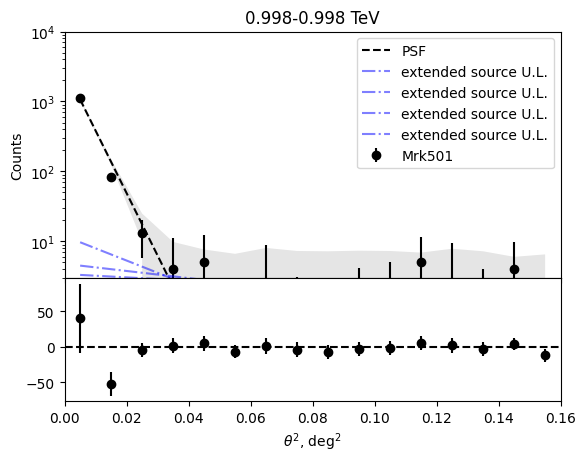

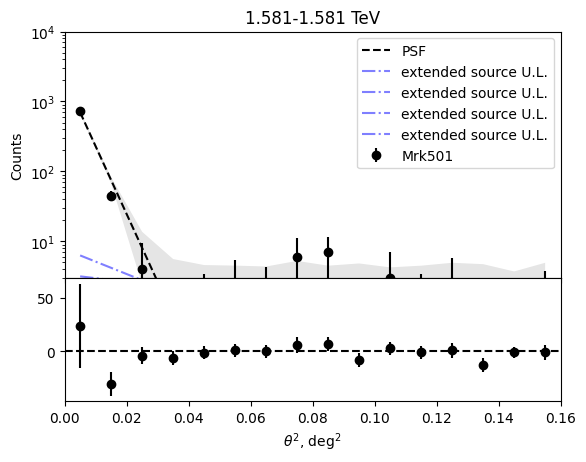

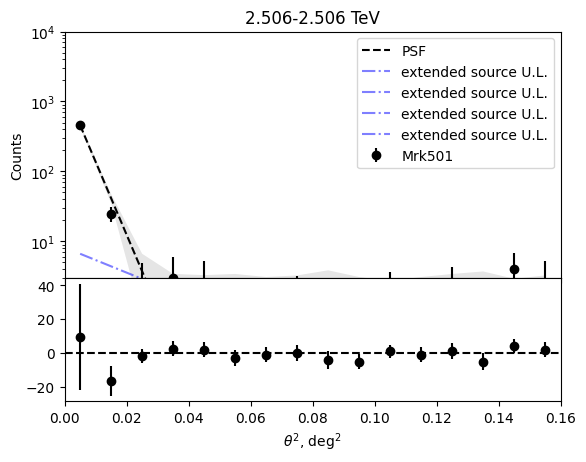

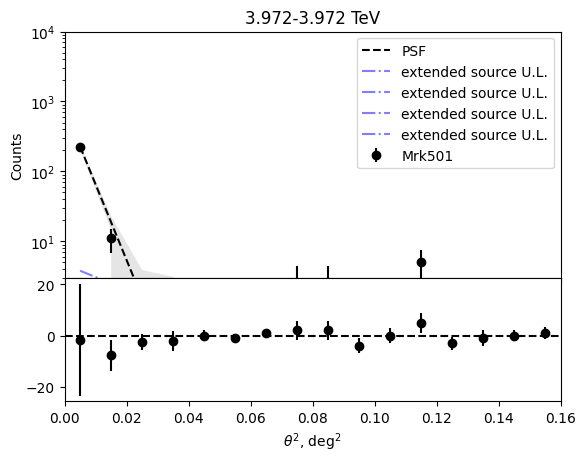

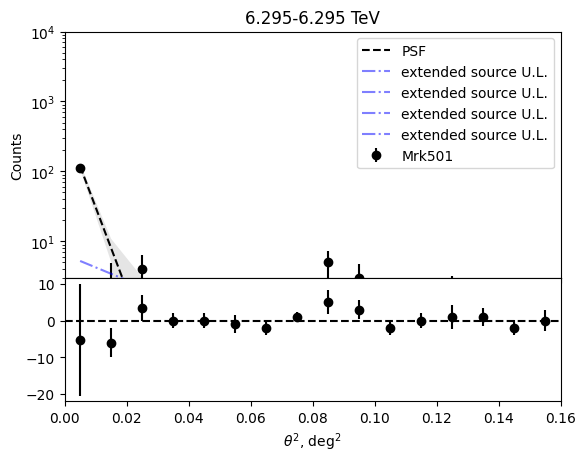

In [10]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
flux_ratios = np.zeros((len(sigmas_ext), len(e)))
chi2max = 2.71

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    if i>10:
        continue
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the psf component to match total counts of the data
    psf_component *= sum(ct)/sum(psf_component)
    psf_component_err = ct_err*sum(psf_component)/sum(ct)
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    for k, sigma_ext in enumerate(sigmas_ext):
        def ext_model(th2):
            sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
            sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
            sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
            gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
            gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
            gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
            return (gauss1_conv + gauss2_conv + gauss3_conv)

        ct_ext = ext_model(th2)
        ct_ext*=sum(ct)/sum(ct_ext)
        chisq=sum((ct-psf_component-ct_ext)**2/(ct_err**2+psf_component_err**2))

        step=1.01
        chisq_best=1e10
        adjust=1.
        adjust1=1.

        while(chisq<chisq_best):
            chisq_best=chisq
            chisq0=sum((ct-step*adjust*psf_component-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq2=sum((ct-adjust*psf_component-step*adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq3=sum((ct-adjust*psf_component-adjust1*ct_ext/step)**2/(ct_err**2+(psf_component_err)**2))
            chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
            chisq=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            if(chisq<chisq_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                if(ind==2):
                    adjust1*=step
                if(ind==3):
                    adjust1/=step
        tot_ct_ext=sum(adjust1*ct_ext)

        #Calculation of Upper limit on extended emission
        model_ps=adjust*psf_component
        model_err = psf_component_err
        model_ext=adjust1*ct_ext
        adjust=1.
        adjust1=1.
        chisq_lim=chisq_best
        while(chisq_lim<chisq_best+chi2max):
            chisq_best1=1e10
            adjust1*=step
            chisq=sum((ct-adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
            while(chisq<chisq_best1):
                chisq_best1=chisq
                chisq0=sum((ct-step*adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq1=sum((ct-adjust*model_ps/step-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq_vec=np.array([chisq0,chisq1])
                chisq=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                if(chisq<chisq_best1):
                    if(ind==0):
                        adjust*=step
                    if(ind==1):
                        adjust/=step
            #print('..',adjust,adjust1,adjust1*cts_ext,adjust*cts_point,chisq_lim)
            chisq_lim=chisq_best1
        axs[0].plot(th2,adjust1*model_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
        ext_ul=sum(adjust1*model_ext)
        print('fraction U.L.',ext_ul/(np.sum(psf_component)+tot_ct_ext))
        flux_ratios[k,i]=ext_ul/(np.sum(psf_component)+tot_ct_ext)
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].set_yscale('log')
        axs[0].set_ylim(3e0,1e4)
        axs[0].legend(loc='upper right')
        plt.xlim(0,0.16)

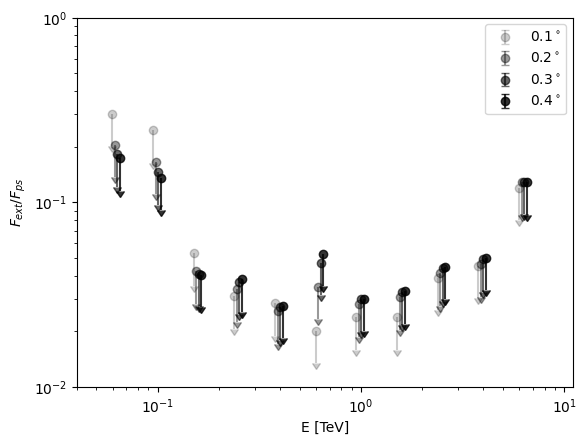

In [11]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()

converged at 
597
2.747779897108762
converged at 
558
2.7240369577643566
converged at 
536
2.7579700004063934
converged at 
524
2.7425117149445253


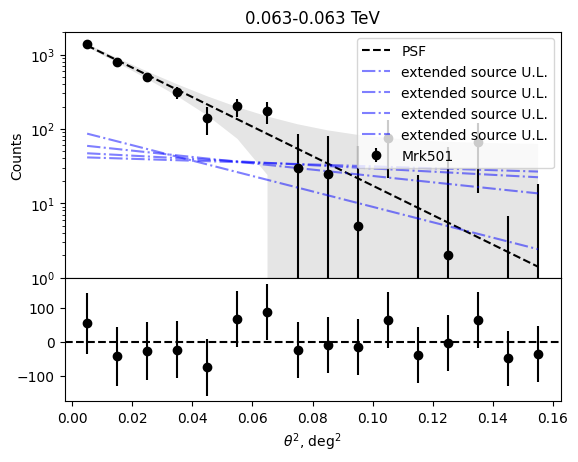

converged at 
620
2.7581345142517124
converged at 
580
2.748411482355829
converged at 
553
2.717867975721357
converged at 
540
2.774140603762115


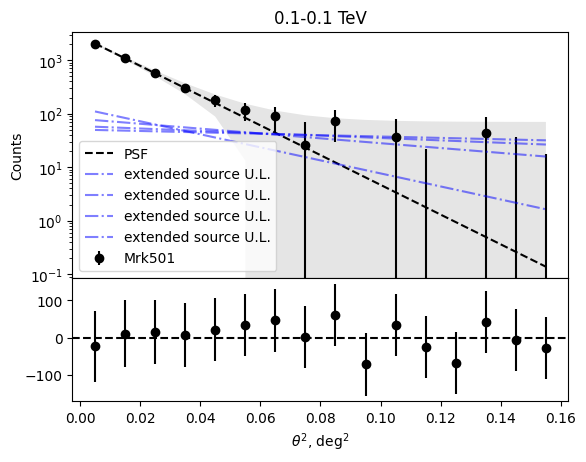

converged at 
599
2.748770720373251
converged at 
532
2.7181721641578944
converged at 
503
2.7196697725116223
converged at 
490
2.7295931377485054


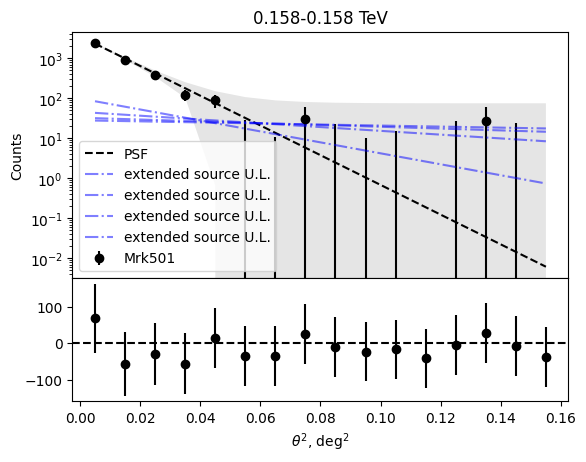

converged at 
612
2.713950711652389
converged at 
550
2.719633568872733
converged at 
524
2.7118199784003973
converged at 
512
2.710212403693803


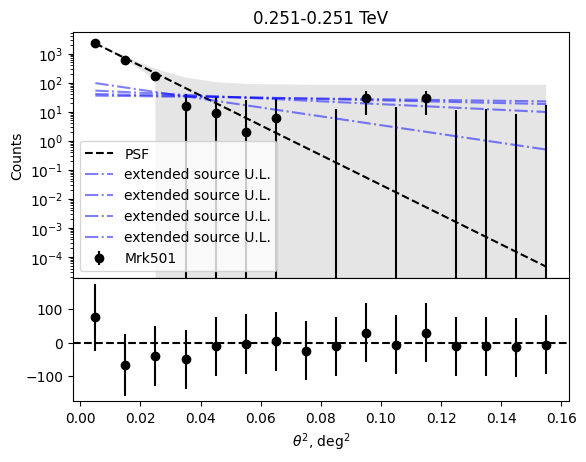

converged at 
625
2.7216810677217973
converged at 
559
2.747854039311034
converged at 
531
2.7418766695551655
converged at 
518
2.722960371421573


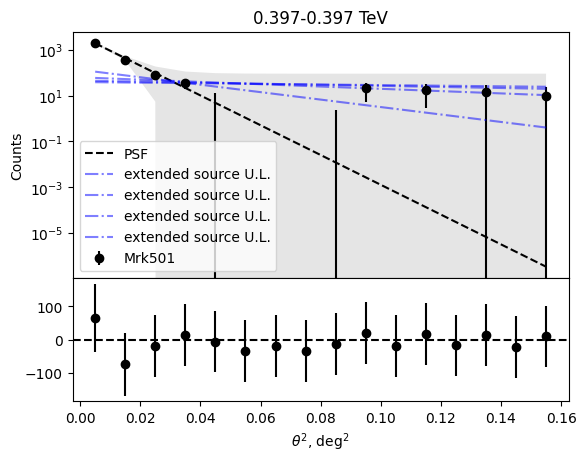

converged at 
632
2.7731228173474882
converged at 
572
2.740164639677756
converged at 
547
2.763367247369138
converged at 
535
2.760351691884689


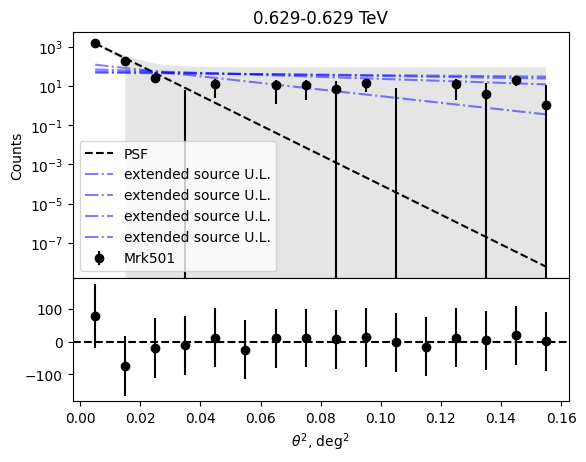

converged at 
635
2.7388023709803813
converged at 
572
2.7425936379310745
converged at 
543
2.7210682400043273
converged at 
530
2.7426973087596647


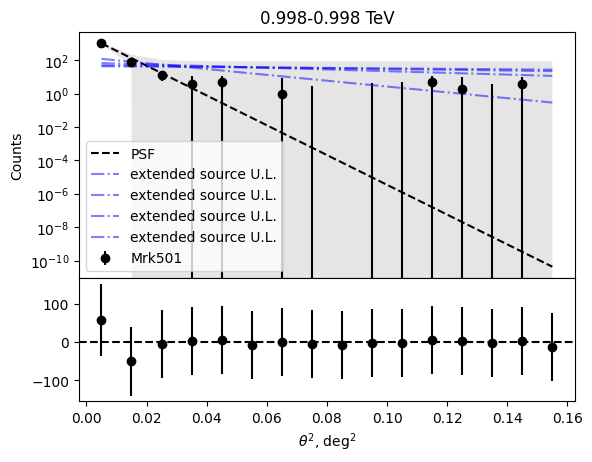

converged at 
623
2.7103215096220197
converged at 
562
2.743498574029974
converged at 
533
2.711162107358858
converged at 
520
2.734258171661974


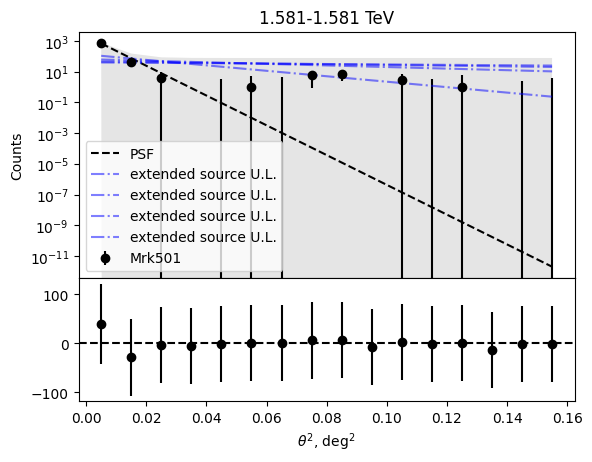

converged at 
610
2.724367200316195
converged at 
551
2.7589760798518546
converged at 
523
2.7490462322596882
converged at 
510
2.752468525688206


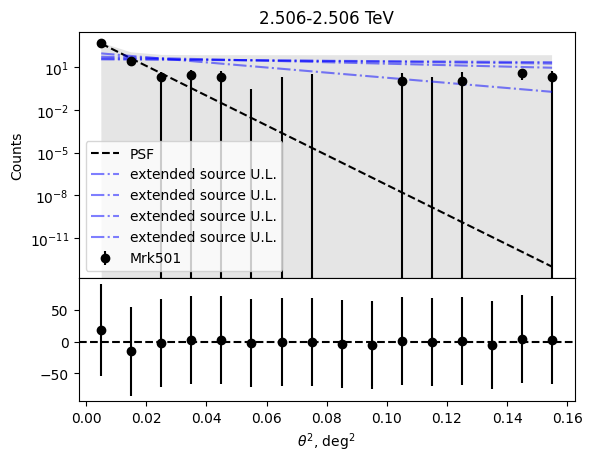

converged at 
580
2.738696251735749
converged at 
522
2.712935948916987
converged at 
495
2.718968040673854
converged at 
483
2.770145987933479


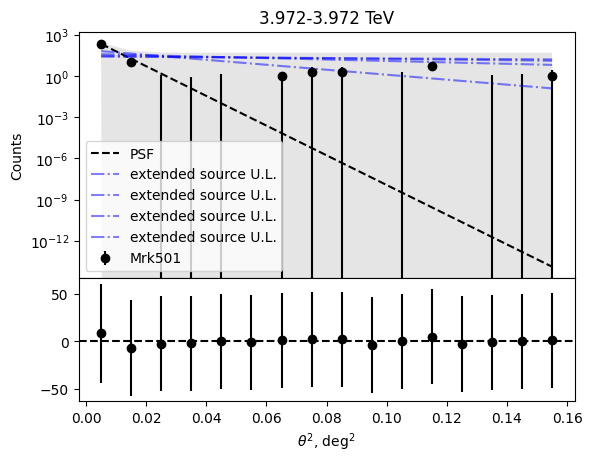

converged at 
561
2.740278940931484
converged at 
505
2.7486762780617955
converged at 
478
2.7532343855983017
converged at 
465
2.7462552435264342


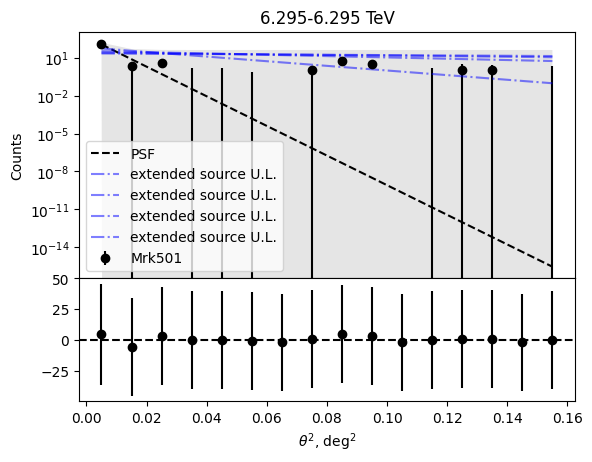

/layers/paketo-buildpacks_conda-env-update/conda-env/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_4078/2134241847.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_point, pcov_point = curve_fit(


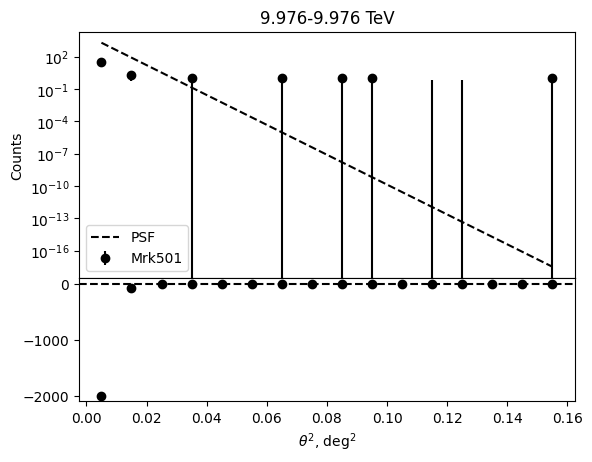

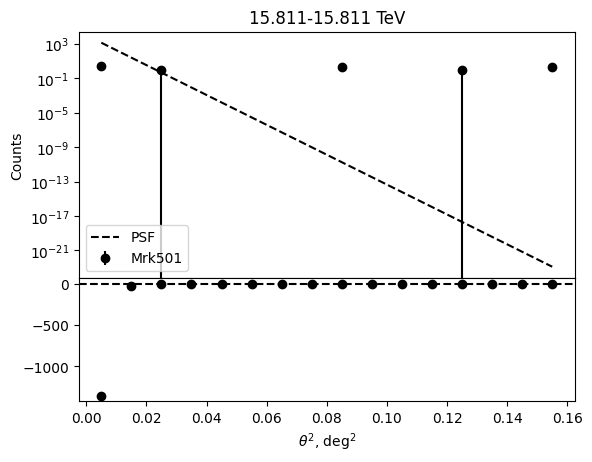

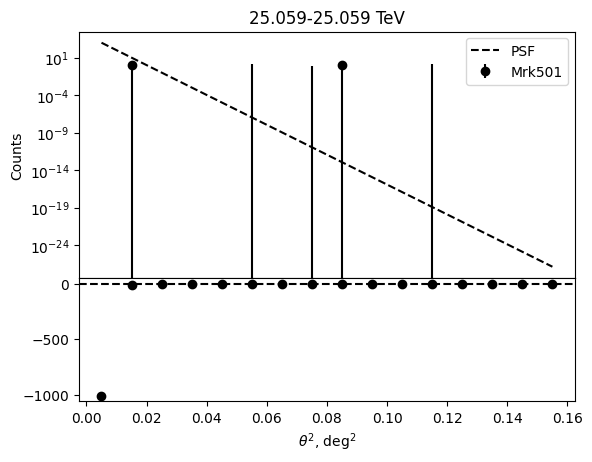

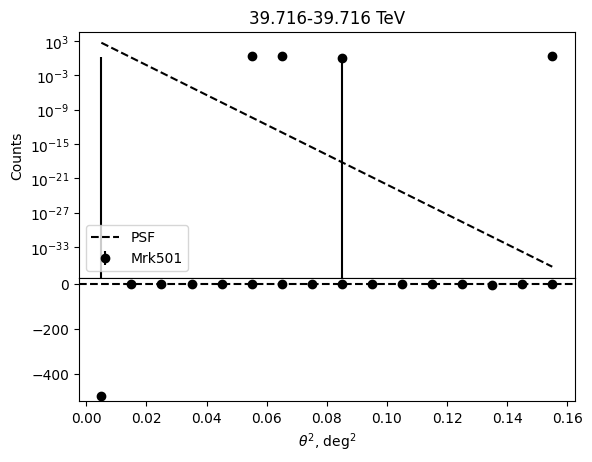

In [12]:
# A modo mio
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.logspace(np.log10(0.1), np.log10(10000), 1000)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = np.argmin(np.abs(psf_e_means - e[i]))
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2, norm):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return norm*(gauss1+gauss2+gauss3)

    init_guess = [10000]
    popt_point, pcov_point = curve_fit(
        psf_model,
        th2,
        ct,
        sigma=ct_err,
        p0 = init_guess,
        absolute_sigma=True
    )
    
    ct_point = psf_model(th2, popt_point)
    ct_point_err = np.sqrt(np.diag(pcov_point))
    chi2_point = np.sum(((ct - ct_point)**2 / (ct_err**2 + ct_point_err**2)))
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,ct_point,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(ct_point-ct_point_err),(ct_point+ct_point_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - ct_point,np.sqrt(ct_err**2+ct_point_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
    # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
    # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            ct_point_and_ext = ct_ext+ct_point
            chi2_point_and_ext = np.sum(((ct - ct_point_and_ext)**2 / (ct_err**2 + ct_point_err**2)))             
            delta_chi2 = chi2_point_and_ext - chi2_point
            
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(ct_point) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    axs[0].legend()
    axs[0].set_yscale('log')
    plt.show()

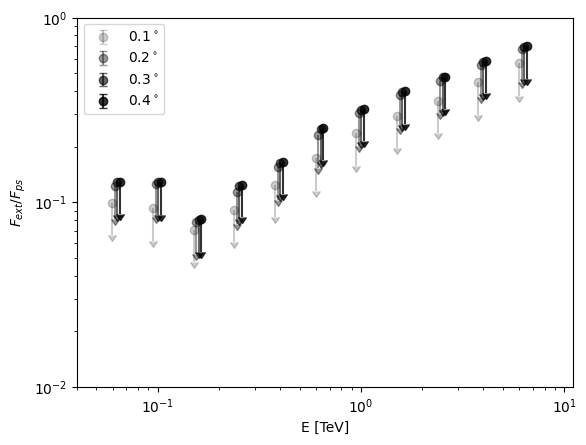

In [13]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()